In [1]:
# import libraries 
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib import colorbar
import seaborn as sns
%matplotlib inline

from wordcloud import WordCloud
from matplotlib.pyplot import figure

import nltk
from nltk import WordNetLemmatizer, pos_tag 
from nltk.corpus import stopwords, wordnet 

from nltk.tokenize import word_tokenize


import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

np.random_state = 42

In [2]:
#pip install wordcloud

In [3]:
sd_listings = pd.read_csv('sd_listings', index_col=0)
sd_listings.head()

,id,listing_url,latitude,longitude,zipcode,name,summary,space,description,neighborhood_overview,notes,transit,access,interaction,house_rules,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,nightly_price,price_per_stay,security_deposit,cleaning_fee,guests_included,extra_people,minimum_nights,maximum_nights,host_id,host_url,host_since,host_about,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,host_total_listings_count,host_has_profile_pic,host_identity_verified,number_of_reviews,number_of_stays,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,requires_license,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification
0,33159143,https://www.airbnb.com/rooms/33159143,32.91736,-117.07635,92131,"PRIVATE ROOM, SAFE NEIGHBORHOOD IN SCRIPPS RANCH",80% of the house + yourCozy room ... in Scripp...,"Full bed, private bath...",80% of the house + yourCozy room ... in Scripp...,The neighborhood is a typical Southern Califor...,Have alarm system if you choose to use... I wi...,You can park in the drive way or plenty of spa...,"Kitchen, Dining room, Living room, Very Comfor...","I lived in San Diego 40+ years, love to share ...",#NAME?,House,Private room,1,1.0,1.0,1.0,Real Bed,"{Wifi,Kitchen,""Free parking on premises"",Heati...",1100.0,1100.0,1000.0,0.0,1,0.0,60,90,249661563,https://www.airbnb.com/users/show/249661563,3/18/19,Retired businessman of 30 years in this commun...,within a few hours,100.0,0,Scripps Ranch,1.0,1,0,0,0,98.0,10.0,10.0,10.0,10.0,10.0,10.0,0,1,0,strict_14_with_grace_period,0,0
1,17138468,https://www.airbnb.com/rooms/17138468,32.84067,-117.27443,92037,NOT AVAILABLE,AVAILABLE ONLY IN WINTER PRIME La Jolla Villag...,NaN,AVAILABLE ONLY IN WINTER PRIME La Jolla Villag...,NaN,NaN,NaN,NaN,NaN,NaN,Apartment,Entire home/apt,1,2.0,2.0,3.0,Real Bed,"{TV,Wifi,""Air conditioning"",Kitchen,""Free park...",1400.0,1400.0,NaN,NaN,1,0.0,30,1125,79755951,https://www.airbnb.com/users/show/79755951,6/24/16,Quiet and considerate.,NaN,0.0,0,La Jolla,1.0,1,0,2,4,100.0,10.0,10.0,10.0,10.0,10.0,10.0,0,1,0,strict_14_with_grace_period,0,0
2,21898446,https://www.airbnb.com/rooms/21898446,32.79797,-117.24250,92109,Townhome in Pacific Beach,Hi! We are basically renting this master for a...,NaN,Hi! We are basically renting this master for a...,NaN,NaN,NaN,NaN,NaN,NaN,Townhouse,Private room,1,1.0,1.0,1.0,Real Bed,"{TV,Wifi,Kitchen,""Free parking on premises"",""P...",1250.0,1250.0,NaN,NaN,1,0.0,30,30,159773487,https://www.airbnb.com/users/show/159773487,11/22/17,NaN,NaN,0.0,0,Pacific Beach,1.0,1,0,0,0,97.0,10.0,10.0,10.0,10.0,10.0,10.0,0,1,0,flexible,0,0
3,25948680,https://www.airbnb.com/rooms/25948680,32.77545,-117.05923,92120,Spacious furnished 1 BR with tons of amenaties,"All my stuff will be gone. Dishwasher, washer/...",Lobby provides free coffee. Building doors loc...,"All my stuff will be gone. Dishwasher, washer/...",College area,NaN,Across the street from the green line trolly. ...,Everything except second bedroom in apartment....,NaN,NaN,Apartment,Entire home/apt,1,1.0,1.0,1.0,Real Bed,"{Wifi,""Air conditioning"",Pool,Kitchen,""Free pa...",1150.0,1150.0,NaN,NaN,1,0.0,31,40,185758729,https://www.airbnb.com/users/show/185758729,4/22/18,NaN,NaN,0.0,0,College Area,1.0,1,0,0,0,98.0,10.0,10.0,10.0,10.0,10.0,10.0,0,0,0,flexible,0,0
4,1756516,https://www.airbnb.com/rooms/1756516,32.84619,-117.27558,92037,A Spacious luxury retreat,"NIcely furnished. Great location, 2 blocks to ...",NaN,"NIcely furnished. Great location, 2 blocks to ...",coastal town great travel destination.,NaN,Bus line near by.,NaN,Call/text business hours.,No pets. Clean and healthy.,Condominium,Private room,1,1.0,1.0,1.0,Real Bed,"{TV,Wifi,Kitchen,""Free parking on premises"",El...",110.0,110.0,200.0,NaN,1,50.0,180,365,3634860,https://www.air

### Split dataframe into text columns only

In [4]:
sd_listings.columns

Index(['id', 'listing_url', 'latitude', 'longitude', 'zipcode', 'name',
       'summary', 'space', 'description', 'neighborhood_overview', 'notes',
       'transit', 'access', 'interaction', 'house_rules', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'bed_type', 'amenities', 'nightly_price', 'price_per_stay',
       'security_deposit', 'cleaning_fee', 'guests_included', 'extra_people',
       'minimum_nights', 'maximum_nights', 'host_id', 'host_url', 'host_since',
       'host_about', 'host_response_time', 'host_response_rate',
       'host_is_superhost', 'neighbourhood_cleansed',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'number_of_reviews', 'number_of_stays',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'requires_license',

In [5]:
# get text columns
sd_text = sd_listings[['id', 'listing_url', 'name','summary', 'space', 'description', 
                       'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 
                       'house_rules', 'amenities', 'host_about']]

sd_text.head(3)

,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,interaction,house_rules,amenities,host_about
0,33159143,https://www.airbnb.com/rooms/33159143,"PRIVATE ROOM, SAFE NEIGHBORHOOD IN SCRIPPS RANCH",80% of the house + yourCozy room ... in Scripp...,"Full bed, private bath...",80% of the house + yourCozy room ... in Scripp...,The neighborhood is a typical Southern Califor...,Have alarm system if you choose to use... I wi...,You can park in the drive way or plenty of spa...,"Kitchen, Dining room, Living room, Very Comfor...","I lived in San Diego 40+ years, love to share ...",#NAME?,"{Wifi,Kitchen,""Free parking on premises"",Heati...",Retired businessman of 30 years in this commun...
1,17138468,https://www.airbnb.com/rooms/17138468,NOT AVAILABLE,AVAILABLE ONLY IN WINTER PRIME La Jolla Villag...,NaN,AVAILABLE ONLY IN WINTER PRIME La Jolla Villag...,NaN,NaN,NaN,NaN,NaN,NaN,"{TV,Wifi,""Air conditioning"",Kitchen,""Free park...",Quiet and considerate.
2,21898446,https://www.airbnb.com/rooms/21898446,Townhome in Pacific Beach,Hi! We are basically renting this master for a...,NaN,Hi! We are basically renting this master for a...,NaN,NaN,NaN,NaN,NaN,NaN,"{TV,Wifi,Kitchen,""Free parking on premises"",""P...",NaN


In [6]:
sd_text.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13051 entries, 0 to 13050
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     13051 non-null  int64 
 1   listing_url            13051 non-null  object
 2   name                   13051 non-null  object
 3   summary                12635 non-null  object
 4   space                  10080 non-null  object
 5   description            12836 non-null  object
 6   neighborhood_overview  9138 non-null   object
 7   notes                  7103 non-null   object
 8   transit                8261 non-null   object
 9   access                 8224 non-null   object
 10  interaction            8665 non-null   object
 11  house_rules            9587 non-null   object
 12  amenities              13051 non-null  object
 13  host_about             8990 non-null   object
dtypes: int64(1), object(13)
memory usage: 1.5+ MB


### Normalizing and Tokenizing

In [7]:
#import stop words
stop_words = stopwords.words('english')


* **Normalization** helps treat `"Pool"`, `"pool"`, and `"POOL"` as the same feature.
* **Tokenization** converts the cleaned description into words so the vectorizer can count or weight them.

Example:

Listing 1:

```
Beautiful Pool
```

Listing 2:

```
beautiful pool
```

Without normalization:

```
Beautiful
beautiful
Pool
pool
```

These become four separate features.

With normalization:

```
beautiful
pool
```

Only two features remain, making the representation more meaningful.

---

### Workflow for `sd_text`

```text
Raw Text
      ↓
Normalization
(lowercase, remove punctuation, lemmatize, etc.)
      ↓
Tokenization
(split into words)
      ↓
Feature Extraction
(TF-IDF / CountVectorizer / Embeddings)
      ↓
Recommendation Model
```

In summary, **normalization standardizes the content of the text**, while **tokenization divides the text into units that NLP models can process**. They are complementary steps, and in most text-based recommendation systems, normalization is performed before tokenization.


In [8]:
# takes in untokenized document and returns fully normalized token list
def process_doc(doc):

    #initialize lemmatizer
    wnl = WordNetLemmatizer()

    # helper function to change nltk's part of speech tagging to a wordnet format.
    def pos_tagger(nltk_tag):
        if nltk_tag.startswith('J'):
            return wordnet.ADJ
        elif nltk_tag.startswith('V'):
            return wordnet.VERB
        elif nltk_tag.startswith('N'):
            return wordnet.NOUN
        elif nltk_tag.startswith('R'):
            return wordnet.ADV
        else:         
            return None
        
    # remove stop words and punctuations, then lower case
    doc_norm = [tok.lower() for tok in word_tokenize(doc) if ((tok.isalpha()) & (tok not in stop_words)) ]

    #  POS detection on the result will be important in telling Wordnet's lemmatizer how to lemmatize
    
    # creates list of tuples with tokens and POS tags in wordnet format
    wordnet_tagged = list(map(lambda x: (x[0], pos_tagger(x[1])), pos_tag(doc_norm))) 
    doc_norm = [wnl.lemmatize(token, pos) for token, pos in wordnet_tagged if pos is not None]
    
    return doc_norm

# This function performs **text preprocessing** on an untokenized document and returns a list of **clean, normalized tokens**. It is commonly used before creating **TF-IDF vectors**, **Bag of Words**, or **recommendation systems**.

Let's go through it line by line.

---

# Function Definition

```python
def process_doc(doc):
```

### What it does

* Takes one document (a string) as input.
* Example:

```python
doc = "The rooms were beautifully decorated and running smoothly."
```

The goal is to convert this raw text into clean words that a machine learning model can understand.

---

# Step 1: Initialize Lemmatizer

```python
wnl = WordNetLemmatizer()
```

### What is a lemmatizer?

A lemmatizer converts words into their **dictionary (base) form**.

Examples

| Original | Lemma |
| -------- | ----- |
| running  | run   |
| rooms    | room  |
| better   | good  |
| cars     | car   |

### Why?

Instead of treating

```
run
running
runs
ran
```

as four different words, we treat them as one word:

```
run
```

This reduces the vocabulary size.

---

# Step 2: Helper Function for POS Tags

```python
def pos_tagger(nltk_tag):
```

This function converts **NLTK POS tags** into **WordNet POS tags**.

---

### Why is this needed?

WordNet lemmatizer needs to know **what type of word** it is.

Example:

```
running
```

can be

Verb

```
I am running.
```

or

Noun

```
Running is healthy.
```

The base form depends on the part of speech.

---

### This block

```python
if nltk_tag.startswith('J'):
    return wordnet.ADJ
```

means

```
JJ
JJR
JJS
```

(all adjective tags)

become

```
wordnet.ADJ
```

---

Similarly

```python
elif nltk_tag.startswith('V'):
    return wordnet.VERB
```

maps

```
VB
VBD
VBG
```

to

```
VERB
```

---

For nouns

```python
elif nltk_tag.startswith('N'):
```

returns

```
wordnet.NOUN
```

---

For adverbs

```python
elif nltk_tag.startswith('R'):
```

returns

```
wordnet.ADV
```

---

Otherwise

```python
return None
```

because WordNet doesn't know how to process other tags.

---

# Step 3: Tokenization + Cleaning

```python
doc_norm = [tok.lower() for tok in word_tokenize(doc)
            if ((tok.isalpha()) & (tok not in stop_words))]
```

This is doing **four preprocessing steps at once**.

---

## (a) Tokenization

```python
word_tokenize(doc)
```

Suppose

```python
doc = "The Rooms are CLEAN!! Near the Beach."
```

becomes

```python
['The',
 'Rooms',
 'are',
 'CLEAN',
 '!',
 '!',
 'Near',
 'the',
 'Beach',
 '.']
```

Now the sentence is split into individual tokens.

---

## (b) Remove punctuation

```python
tok.isalpha()
```

Only keeps alphabetic words.

So

```
!
.
123
$
```

are removed.

Result

```python
['The',
 'Rooms',
 'are',
 'CLEAN',
 'Near',
 'the',
 'Beach']
```

---

## (c) Remove stop words

```python
tok not in stop_words
```

Stop words are very common words that usually add little meaning, such as:

```
the
is
are
of
and
to
```

So

```
The
are
the
```

are removed.

Result

```python
['Rooms',
 'CLEAN',
 'Near',
 'Beach']
```

---

## (d) Convert to lowercase

```python
tok.lower()
```

Now

```
Rooms
CLEAN
Beach
```

become

```
rooms
clean
beach
```

Final output of this step

```python
['rooms',
 'clean',
 'near',
 'beach']
```

This list is stored in

```python
doc_norm
```

---

# Step 4: POS Tagging

```python
wordnet_tagged = list(
    map(lambda x: (x[0], pos_tagger(x[1])),
        pos_tag(doc_norm))
)
```

This is the most advanced part of the function.

---

## First

```python
pos_tag(doc_norm)
```

takes

```python
['rooms',
 'clean',
 'near',
 'beach']
```

and assigns a grammatical role to each word.

Example

```python
[
('rooms','NNS'),
('clean','JJ'),
('near','IN'),
('beach','NN')
]
```

Meaning

| Word  | POS         |
| ----- | ----------- |
| rooms | plural noun |
| clean | adjective   |
| near  | preposition |
| beach | noun        |

---

## Next

The `map` function applies

```python
pos_tagger()
```

to convert NLTK tags into WordNet tags.

Result

```python
[
('rooms', wordnet.NOUN),
('clean', wordnet.ADJ),
('near', None),
('beach', wordnet.NOUN)
]
```

Notice

```
near
```

became

```
None
```

because it's a preposition, and your helper function doesn't map prepositions.

---

# Step 5: Lemmatization

```python
doc_norm = [
    wnl.lemmatize(token, pos)
    for token, pos in wordnet_tagged
    if pos is not None
]
```

Now each word is converted into its base form using its POS tag.

Example

Input

```python
[
('rooms', NOUN),
('running', VERB),
('cars', NOUN)
]
```

becomes

```python
[
'room',
'run',
'car'
]
```

Notice

```
running
```

becomes

```
run
```

only because we told the lemmatizer it is a **verb**.

If we hadn't provided the POS tag, the lemmatizer might leave `"running"` unchanged or produce a less accurate result.

Words with `pos = None` (like prepositions) are skipped due to:

```python
if pos is not None
```

---

# Step 6: Return the Processed Tokens

```python
return doc_norm
```

Final output

```python
['room',
'clean',
'beach']
```

This is a **fully normalized token list**.

---

# Complete Flow

Suppose the input is:

```text
"The Rooms are CLEAN!! They were running near the Beaches."
```

| Step               | Output                                                                           |
| ------------------ | -------------------------------------------------------------------------------- |
| Raw text           | `"The Rooms are CLEAN!! They were running near the Beaches."`                    |
| Tokenization       | `['The','Rooms','are','CLEAN','They','were','running','near','the','Beaches']`   |
| Remove punctuation | `['The','Rooms','are','CLEAN','They','were','running','near','the','Beaches']`   |
| Remove stop words  | `['Rooms','CLEAN','running','near','Beaches']`                                   |
| Lowercase          | `['rooms','clean','running','near','beaches']`                                   |
| POS tagging        | `[('rooms',NOUN),('clean',ADJ),('running',VERB),('near',None),('beaches',NOUN)]` |
| Lemmatization      | `['room','clean','run','beach']`                                                 |

---

### Why all these steps are needed

Each preprocessing step improves the quality of the text representation:

* **Tokenization** splits raw text into individual words.
* **Lowercasing** ensures `"Pool"` and `"pool"` are treated as the same word.
* **Removing punctuation and non-alphabetic tokens** eliminates noise.
* **Removing stop words** keeps only the words that carry useful meaning.
* **POS tagging** identifies each word's grammatical role so the lemmatizer can choose the correct base form.
* **Lemmatization** reduces different forms of the same word (e.g., `"rooms"` → `"room"`, `"running"` → `"run"`), reducing vocabulary size and improving similarity calculations.

For an Airbnb recommendation system, this produces a clean, standardized set of tokens from each listing description, making techniques like **TF-IDF** or **cosine similarity** much more effective because listings with similar meanings are represented more consistently.


In one sentence

pos_tag() identifies the grammatical role of each word (using NLTK tag names like VBG, NN, JJ).

wordnet provides the POS constants (VERB, NOUN, ADJ, ADV) that WordNetLemmatizer understands.
The pos_tagger() helper function converts NLTK's tags into the format required by WordNet. Without this conversion, the lemmatizer cannot correctly use the detected POS information.

### Fill in missing entries

In [9]:
# fill in NaNs with empty text fields
sd_text = sd_text.fillna(" ")
sd_text.head(3)

,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,interaction,house_rules,amenities,host_about
0,33159143,https://www.airbnb.com/rooms/33159143,"PRIVATE ROOM, SAFE NEIGHBORHOOD IN SCRIPPS RANCH",80% of the house + yourCozy room ... in Scripp...,"Full bed, private bath...",80% of the house + yourCozy room ... in Scripp...,The neighborhood is a typical Southern Califor...,Have alarm system if you choose to use... I wi...,You can park in the drive way or plenty of spa...,"Kitchen, Dining room, Living room, Very Comfor...","I lived in San Diego 40+ years, love to share ...",#NAME?,"{Wifi,Kitchen,""Free parking on premises"",Heati...",Retired businessman of 30 years in this commun...
1,17138468,https://www.airbnb.com/rooms/17138468,NOT AVAILABLE,AVAILABLE ONLY IN WINTER PRIME La Jolla Villag...,,AVAILABLE ONLY IN WINTER PRIME La Jolla Villag...,,,,,,,"{TV,Wifi,""Air conditioning"",Kitchen,""Free park...",Quiet and considerate.
2,21898446,https://www.airbnb.com/rooms/21898446,Townhome in Pacific Beach,Hi! We are basically renting this master for a...,,Hi! We are basically renting this master for a...,,,,,,,"{TV,Wifi,Kitchen,""Free parking on premises"",""P...",


In [10]:
def tokenize_df(df):
    """
    Helper function tokenizes each column in the dataframe.
    Uses the process_doc helper function to tokenize and normalize each column into string values.
    """
    # get list of column names
    col_names = list(df.columns)

    # just get the relevant text columns
    col_names = col_names[2:]

    # create an empty dataframe
    tokenized_df = pd.DataFrame()

    # tokenize each column
    for col in col_names:

        # tokenize and join tokens back into a string
        tokenized_series = df[col].apply(process_doc).apply(" ".join)

        # convert each column into a dataframe
        tokenized_col = tokenized_series.to_frame().transpose()

        # append using pd.concat (replacement for append())
        tokenized_df = pd.concat([tokenized_df, tokenized_col])

    # transpose back so rows represent listings
    tokenized_df = tokenized_df.transpose()

    # merge id and listing_url back
    tokenized_df = df.iloc[:, [0, 1]].join(tokenized_df)

    return tokenized_df

In [11]:
tokenized_text = tokenize_df(sd_text)
tokenized_text.head()


KeyboardInterrupt



In [12]:
# save as csv
path = "data/"

tokenized_text.to_csv('tokenized_text')

NameError: name 'tokenized_text' is not defined

In [13]:
tokenized_text = pd.read_csv('tokenized_text', index_col= 0)
tokenized_text = tokenized_text.fillna(' ')
tokenized_text.head(3)

,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,interaction,house_rules,amenities,host_about
0,33159143,https://www.airbnb.com/rooms/33159143,private room safe neighborhood scripps ranch,house yourcozy room scripps ranch decor safe f...,full bed private bath,house yourcozy room scripps ranch decor safe f...,neighborhood typical southern california spani...,have alarm system choose use i supply butane b...,park drive way plenty space next house,kitchen din room living room very comfortable ...,i live san diego year love share neat place ci...,name,wifi kitchen free parking premise heat dryer s...,retire businessman year community be se asia i...
1,17138468,https://www.airbnb.com/rooms/17138468,not available,available only winter prime la jolla village l...,,available only winter prime la jolla village l...,,,,,,,tv wifi air condition kitchen free parking pre...,quiet considerate
2,21898446,https://www.airbnb.com/rooms/21898446,townhome pacific beach,hi basically rent master month move date room ...,,hi basically rent master month move date room ...,,,,,,,tv wifi kitchen free parking premise pet allow...,


In short, **`tokenized_df` contains the same Airbnb listings as the original dataframe, but with all text columns cleaned and tokenized**.

### Original `sd_text`

| id | listing_url | name           | description                                        |
| -- | ----------- | -------------- | -------------------------------------------------- |
| 1  | url1        | Cozy Apartment | Beautiful apartment near the beach with free WiFi. |

### After `tokenize_df()`

| id | listing_url | name           | description                              |
| -- | ----------- | -------------- | ---------------------------------------- |
| 1  | url1        | cozy apartment | beautiful apartment near beach free wifi |

### What's changed?

* ✅ Converted to lowercase
* ✅ Removed punctuation
* ✅ Removed stopwords (e.g., "the", "with")
* ✅ Lemmatized words (e.g., "houses" → "house")
* ✅ Joined the cleaned tokens back into a string

### Why is it needed?

The cleaned text is much easier for algorithms like **TF-IDF**, **CountVectorizer**, or **Word2Vec** to convert into numerical features, which are then used to build the recommendation system.


Data Visualization
Now that the text for each listing category has been tokenized, let's explore the distribution of words using a simple wordcloud for some of the features.

### Airbnb Listing Descriptions
#### Name

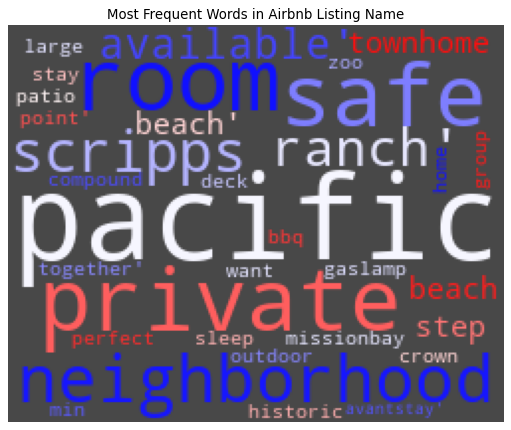

In [14]:
# creates an array of all values in the name column
name = tokenized_text['name'].values

# create wordcloud
name_wordcloud = WordCloud(background_color = '#484848',
                           colormap = 'bwr',
                           max_font_size = 100,
                           width = 250,
                           height = 200,
                           random_state = 10).generate(str(name))

# show fig
figure(figsize=(8, 8), dpi=80)
plt.imshow(name_wordcloud)
plt.title('Most Frequent Words in Airbnb Listing Name')
plt.axis('off')

# name_wordcloud.to_file('images/wordcloud_name.png')
plt.show()

This **word cloud** visualizes the most frequently occurring words in the **Airbnb listing names** after tokenization and preprocessing (removing stop words, punctuation, and normalizing text).

### Role of the Word Cloud

A word cloud is an **exploratory data analysis (EDA)** tool used to quickly identify the most common words in a text dataset.

Its main purposes are:

* Understand the overall themes in listing names.
* Identify frequently used keywords.
* Detect repetitive or generic terms.
* Help decide which words may be useful or should be removed before building recommendation models.

### Insights from the Word Cloud

From your visualization, we can observe:

* **"pacific"** is one of the largest words, indicating that many listings mention the Pacific Beach area.
* **"private"** appears very frequently, suggesting hosts emphasize private rooms or private spaces.
* **"room"** is another dominant term, showing many listings are rooms rather than entire homes.
* **"safe"** appears often, indicating hosts commonly advertise neighborhood safety.
* **"neighborhood"** is frequently used, highlighting the importance of location.
* **"scripps"**, **"ranch"**, and **"missionbay"** indicate popular neighborhoods or landmarks.
* Words like **"beach"**, **"patio"**, **"bbq"**, **"deck"**, and **"outdoor"** describe amenities or nearby attractions.
* Smaller words such as **"historic"**, **"townhome"**, **"zoo"**, and **"gaslamp"** represent less frequently mentioned but still relevant features.

### Why is this useful for the recommendation system?

The word cloud helps you:

* Understand what hosts commonly advertise.
* Verify that tokenization worked correctly.
* Discover important keywords that can improve **content-based recommendations**.
* Identify generic words (e.g., *room*, *private*) that may have low discriminative value and could potentially be down-weighted or removed in feature engineering.



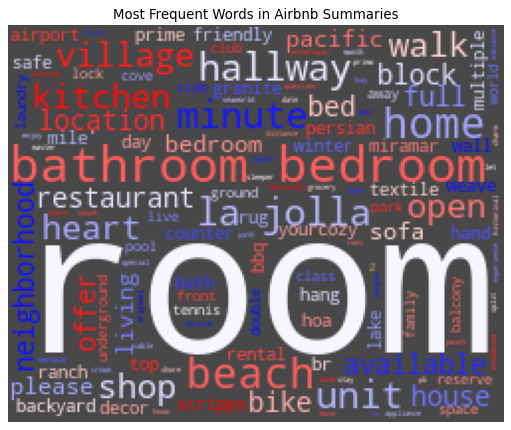

In [15]:
# creates an array of all values in the name column
summary = tokenized_text['summary'].values

# create wordcloud
summary_wordcloud = WordCloud(background_color = '#484848',
                           colormap = 'bwr',
                           max_font_size = 100,
                           width = 250,
                           height = 200,
                           random_state = 10).generate(str(summary))

# show fig
figure(figsize=(8, 8), dpi = 80)
plt.imshow(summary_wordcloud)
plt.title('Most Frequent Words in Airbnb Summaries')
plt.axis('off')

# summary_wordcloud.to_file('images/wordcloud_summary.png')
plt.show()

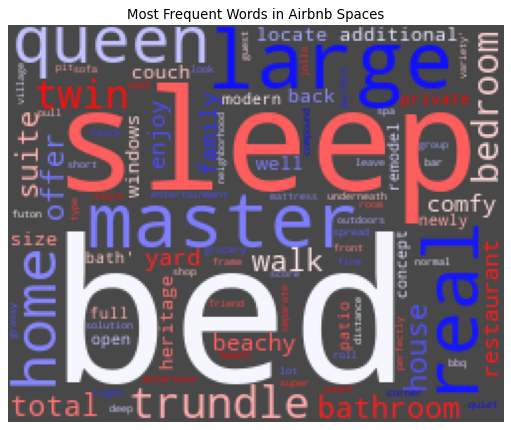

In [16]:
# creates an array of all values in the name column
space = tokenized_text['space'].values

# create wordcloud
space_wordcloud = WordCloud(background_color = '#484848',
                           colormap = 'bwr',
                           max_font_size = 100,
                           width = 250,
                           height = 200,
                           random_state = 10).generate(str(space))

# show fig
figure(figsize=(8, 8), dpi = 80)
plt.imshow(space_wordcloud)
plt.title('Most Frequent Words in Airbnb Spaces')
plt.axis('off')

# space_wordcloud.to_file('images/wordcloud_space.png')
plt.show()


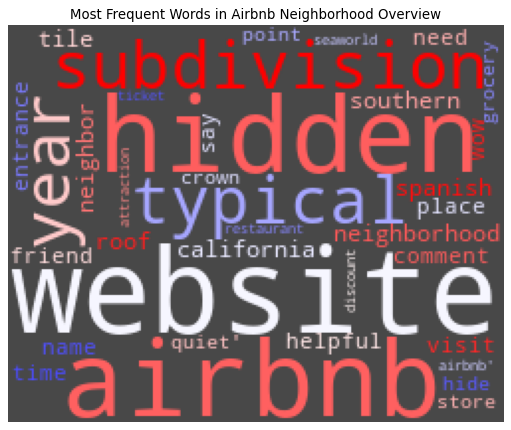

In [17]:
# creates an array of all values in the name column
neighborhood = tokenized_text['neighborhood_overview'].values

# create wordcloud
neighborhood_wordcloud = WordCloud(background_color = '#484848',
                           colormap = 'bwr',
                           max_font_size = 100,
                           width = 250,
                           height = 200,
                           random_state = 10).generate(str(neighborhood))

# show fig
figure(figsize=(8, 8), dpi = 80)
plt.imshow(neighborhood_wordcloud)
plt.title('Most Frequent Words in Airbnb Neighborhood Overview')
plt.axis('off')

# neighborhood_wordcloud.to_file('images/wordcloud_neighborhood.png')
plt.show()

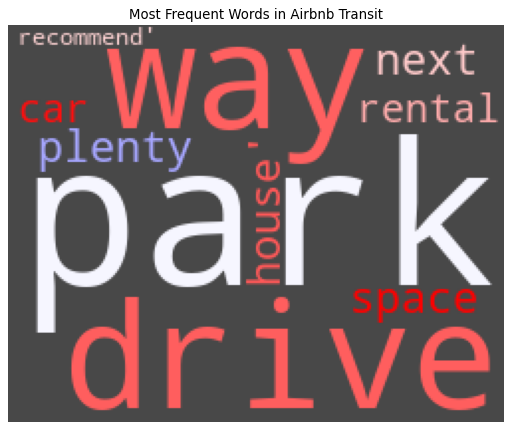

In [18]:
# creates an array of all values in the name column
transit = tokenized_text['transit'].values

# create wordcloud
transit_wordcloud = WordCloud(background_color = '#484848',
                           colormap = 'bwr',
                           max_font_size = 100,
                           width = 250,
                           height = 200,
                           random_state = 10).generate(str(transit))

# show fig
figure(figsize=(8, 8), dpi = 80)
plt.imshow(transit_wordcloud)
plt.title('Most Frequent Words in Airbnb Transit')
plt.axis('off')

# transit_wordcloud.to_file('images/wordcloud_transit.png')
plt.show()

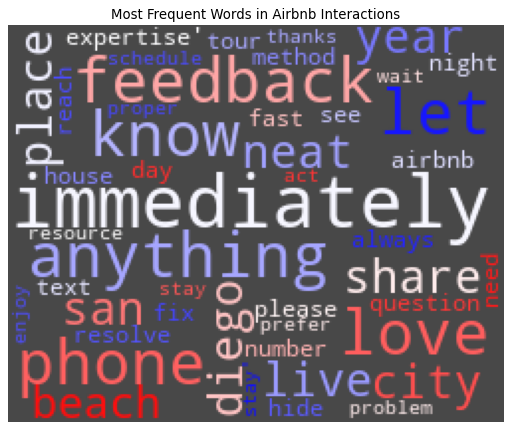

In [19]:
# creates an array of all values in the name column
interaction = tokenized_text['interaction'].values

# create wordcloud
interaction_wordcloud = WordCloud(background_color = '#484848',
                           colormap = 'bwr',
                           max_font_size = 100,
                           width = 250,
                           height = 200,
                           random_state = 10).generate(str(interaction))

# show fig
figure(figsize=(8, 8), dpi = 80)
plt.imshow(interaction_wordcloud)
plt.title('Most Frequent Words in Airbnb Interactions')
plt.axis('off')

# interaction_wordcloud.to_file('images/wordcloud_interaction.png')
plt.show()

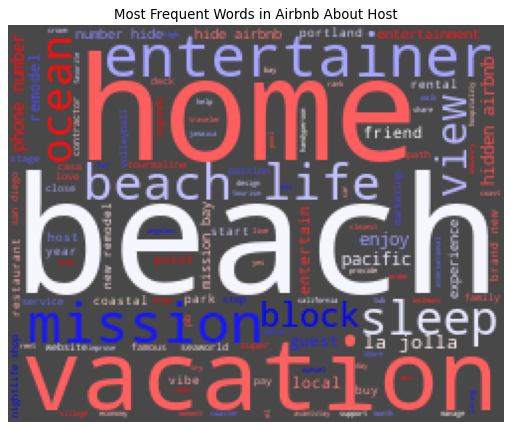

In [20]:
# creates an array of all values in the name column
host = tokenized_text['host_about'].values

# create wordcloud
host_wordcloud = WordCloud(background_color = '#484848',
                           colormap = 'bwr',
                           max_font_size = 100,
                           width = 250,
                           height = 200,
                           random_state = 10).generate(str(host))

# show fig
figure(figsize=(8, 8), dpi = 80)
plt.imshow(host_wordcloud)
plt.title('Most Frequent Words in Airbnb About Host')
plt.axis('off')

# host_wordcloud.to_file('images/wordcloud_host.png')
plt.show()



* Listings frequently emphasize **beautiful locations**, especially beaches and scenic views, to attract guests.
* Terms like **"hidden gem"** are commonly used, indicating a popular marketing strategy rather than a unique characteristic.
* Amenities such as **WiFi, TV, parking, and large beds** are among the most frequently advertised features, highlighting what hosts believe guests value most.
* Some listing descriptions and host profiles contain occupation-related terms associated with **creative and entertainment professions**, suggesting that many hosts may rent out properties as a supplementary source of income.


### Sentiment Analysis

Sentiment analysis is used to understand the overall tone of Airbnb listing descriptions. In this project, the **TextBlob** library is used to calculate two sentiment scores for each text field:

- **Polarity:** Measures how positive or negative the text is, with values ranging from **-1** (most negative) to **+1** (most positive). A value close to **0** indicates neutral sentiment.
- **Subjectivity:** Measures how opinion-based or factual the text is, with values ranging from **0** (completely factual) to **1** (highly subjective or opinion-based).

These sentiment scores help analyze how hosts describe their listings and can provide useful insights into the language used across Airbnb properties.

In [21]:
#pip install textblob

In [22]:
from textblob import TextBlob

In [23]:
pol = lambda x : TextBlob(x).sentiment.polarity
sub = lambda x : TextBlob(x).sentiment.subjectivity

#get list of column names
col_names = list(sd_text.columns)
# just get the relevant text columns
col_names = col_names[2:]

for col in col_names:
    tokenized_text[col+'_polarity'] = tokenized_text[col].apply(pol)
    tokenized_text[col+'_subjectivity'] = tokenized_text[col].apply(sub)
tokenized_text.head()

,id,listing_url,name,summary,space,description,neighborhood_overview,notes,transit,access,interaction,house_rules,amenities,host_about,name_polarity,name_subjectivity,summary_polarity,summary_subjectivity,space_polarity,space_subjectivity,description_polarity,description_subjectivity,neighborhood_overview_polarity,neighborhood_overview_subjectivity,notes_polarity,notes_subjectivity,transit_polarity,transit_subjectivity,access_polarity,access_subjectivity,interaction_polarity,interaction_subjectivity,house_rules_polarity,house_rules_subjectivity,amenities_polarity,amenities_subjectivity,host_about_polarity,host_about_subjectivity
0,33159143,https://www.airbnb.com/rooms/33159143,private room safe neighborhood scripps ranch,house yourcozy room scripps ranch decor safe f...,full bed private bath,house yourcozy room scripps ranch decor safe f...,neighborhood typical southern california spani...,have alarm system choose use i supply butane b...,park drive way plenty space next house,kitchen din room living room very comfortable ...,i live san diego year love share neat place ci...,name,wifi kitchen free parking premise heat dryer s...,retire businessman year community be se asia i...,0.25,0.4375,0.343750,0.375000,0.17500,0.46250,0.185178,0.438725,-0.038889,0.388889,0.0,0.0,0.0,0.0,0.52,1.0,0.378788,0.566667,0.000000,0.0,0.133333,0.491667,0.16,0.380000
1,17138468,https://www.airbnb.com/rooms/17138468,not available,available only winter prime la jolla village l...,,available only winter prime la jolla village l...,,,,,,,tv wifi air condition kitchen free parking pre...,quiet considerate,-0.20,0.4000,0.126623,0.492857,0.00000,0.00000,0.126623,0.492857,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000000,0.000000,0.0,0.141667,0.515000,0.00,0.333333
2,21898446,https://www.airbnb.com/rooms/21898446,townhome pacific beach,hi basically rent master month move date room ...,,hi basically rent master month move date room ...,,,,,,,tv wifi kitchen free parking premise pet allow...,,0.00,0.0000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000000,0.000000,0.0,0.111111,0.591667,0.00,0.000000
3,25948680,https://www.airbnb.com/rooms/25948680,spacious furnish br ton amenaties,stuff go dishwasher unit small porch closet re...,lobby provide free coffee building door lock n...,stuff go dishwasher unit small porch closet re...,college area,,street green line trolly stop sdsu freeway ent...,everything second bedroom apartment vacant lock,,,wifi air condition pool kitchen free parking p...,,0.00,0.0000,0.005506,0.274256,0.29375,0.74375,0.072789,0.390646,0.000000,0.000000,0.0,0.0,-0.2,0.3,0.00,0.0,0.000000,0.000000,0.000000,0.0,0.258333,0.558333,0.00,0.000000
4,1756516,https://www.airbnb.com/rooms/1756516,spacious luxury retreat,nicely furnished great location block beach be...,,nicely furnished great location block beach be...,coastal town great travel destination,,bus line,,business hour,pet clean healthy,tv wifi kitchen free parking premise elevator ...,life short enjoy,0.00,0.0000,0.762500,0.875000,0.00000,0.00000,0.770000,0.850000,0.800000,0.750000,0.0,0.0,0.0,0.0,0.00,0.0,0.000000,0.000000,0.433333,0.6,0.325000,0.825000,0.20,0.400000



# What is the role of this step?

This step is part of **feature engineering**.

The original listing descriptions are text, but machine learning models work best with numerical features. By applying sentiment analysis, each text field is converted into two numeric values:

* **Polarity** (how positive or negative the description is)
* **Subjectivity** (how opinion-based or factual the description is)

These values can then be:

* analyzed to understand how hosts describe their listings,
* included as additional input features for clustering or recommendation models,
* combined with other features such as price, location, amenities, and ratings.

Although sentiment features are usually **less influential** than core features like location or price, they provide extra information about the style and tone of a listing's description, which may help distinguish between otherwise similar listings.


### Make a new dataframe of aggregate polarity & subjectivity for each feature

In [24]:
# define columns
columns = ['Column_Name','Polarity', 'Subjectivity']

# get a list of average polarity and subjectivity for each column
polarity_avg = [tokenized_text[col+'_polarity'].mean() for col in col_names]
subjectivity_avg = [tokenized_text[col+'_subjectivity'].mean() for col in col_names]
# create a new dataframe with average of polarity and subjectivity for each column feature
sentiment_df = pd.DataFrame({'Column_Name': col_names, 'Polarity': polarity_avg, 'Subjectivity': subjectivity_avg}, 
                            index = col_names, 
                            columns = columns)

sentiment_df

,Column_Name,Polarity,Subjectivity
name,name,0.138134,0.318204
summary,summary,0.261239,0.494761
space,space,0.173667,0.374060
description,description,0.247955,0.496335
neighborhood_overview,neighborhood_overview,0.160598,0.304142
notes,notes,0.084473,0.229188
transit,transit,0.123312,0.226147
access,access,0.084049,0.262790
interaction,interaction,0.180851,0.296976
house_rules,house_rules,0.084649,0.321077


Sentiment analysis shows that hosts usually write positive descriptions to make their listings attractive. Promotional sections like Summary and Description have higher positive and subjectivity scores because they contain opinions and appealing language. Informational sections such as Notes, Transit, and House Rules have lower scores because they mainly provide factual information. These sentiment scores can also be used as additional numerical features in the recommendation system. While they are less important than factors like location, price, and amenities, they help capture the writing style and tone of the listing, which can improve recommendations when comparing similar properties.

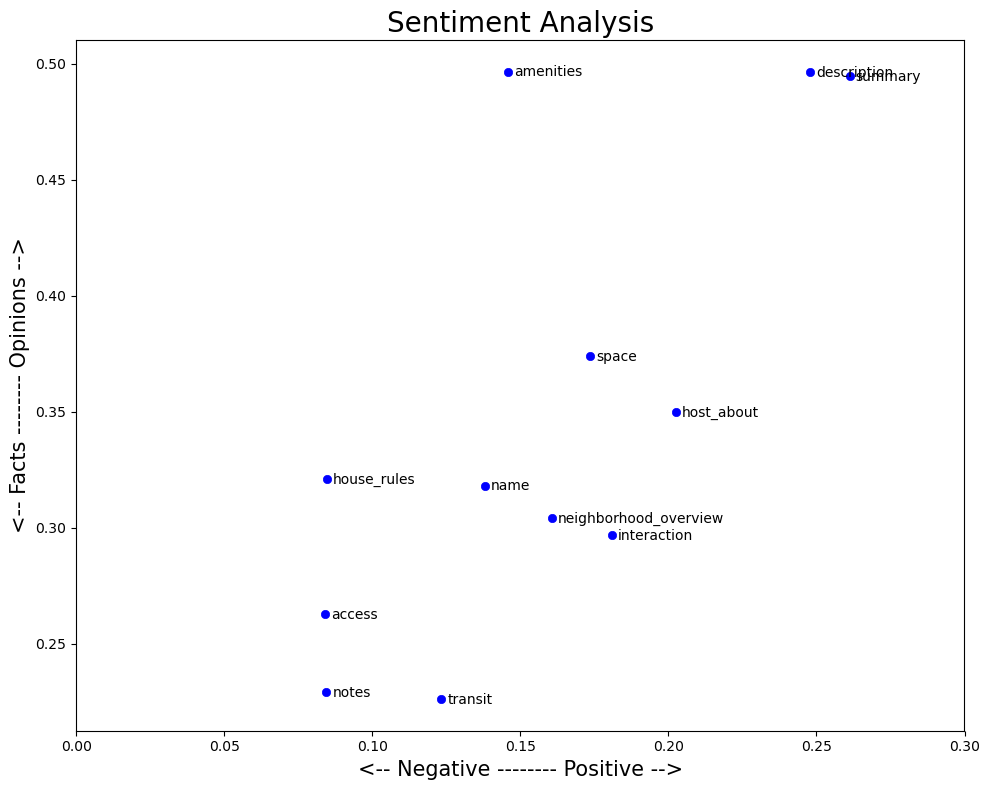

In [26]:
#plot the results
fig , ax = plt.subplots(figsize=(10,8))
plt.style.use('bmh')

for index, col in enumerate(sentiment_df.index):
    x = sentiment_df.Polarity.loc[col]
    y = sentiment_df.Subjectivity.loc[col]
    plt.scatter(x, y, color='blue')
    plt.text(x+.002, y-0.002, sentiment_df['Column_Name'][index], fontsize=10)
    plt.xlim(0, 0.3) 
    
plt.title('Sentiment Analysis', fontsize=20)
plt.xlabel('<-- Negative -------- Positive -->', fontsize=15)
plt.ylabel('<-- Facts -------- Opinions -->', fontsize=15)

plt.tight_layout()
plt.show()


Based on your sentiment analysis plot, here are the key insights you can include in your project report.

### Insights from Sentiment Analysis

1. **Listing descriptions are generally positive**

   * All text fields have **positive polarity values** (greater than 0).
   * None of the sections have negative sentiment, indicating that hosts usually write in a positive and welcoming tone to attract guests.

2. **Summary and Description are the most positive sections**

   * The **Summary** and **Description** fields have the highest polarity scores (around 0.25–0.27).
   * These sections are intended to promote the property, so hosts use attractive words such as *beautiful, cozy, comfortable,* and *perfect*.

3. **Summary, Description, and Amenities are the most subjective**

   * These fields have subjectivity values close to **0.5**, meaning they contain more opinions and promotional language rather than pure facts.
   * This suggests hosts try to persuade potential guests by emphasizing the property's best features.

4. **Notes, Transit, and Access are mostly factual**

   * These fields have the lowest subjectivity scores (around 0.22–0.26).
   * They mainly provide practical information such as transportation, check-in instructions, or important notes, making them more objective.

5. **House Rules are slightly subjective but still informative**

   * House Rules have low positive sentiment and relatively low subjectivity.
   * This indicates that hosts present rules politely while keeping the information clear and instructional.

6. **Host About and Space show balanced sentiment**

   * These sections have moderate positivity and subjectivity.
   * They combine factual details with some personal opinions or descriptive language about the host and the property.

7. **Neighborhood Overview and Interaction are moderately objective**

   * These sections contain useful information about the surrounding area and host interaction while maintaining a neutral and informative tone.

---

### Overall Conclusion

The sentiment analysis shows that Airbnb hosts use **positive language throughout their listings**, especially in promotional sections like **Summary** and **Description**, to make their properties more appealing. On the other hand, sections such as **Notes**, **Transit**, **Access**, and **House Rules** focus on providing factual information, resulting in lower subjectivity scores. These sentiment features can also be used as additional numerical features in the recommendation system to capture the writing style of listings, although they are less influential than factors like **price, location, ratings, and amenities**.
